In [7]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [8]:
file_path='/content/drive/MyDrive/overstimulation_dataset.csv'

In [20]:
# Import the pandas library
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import minmax_scale, StandardScaler
from sklearn.ensemble import RandomForestClassifier # Importing RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report # Importing necessary functions
!pip install matplotlib seaborn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import minmax_scale, StandardScaler
from sklearn.ensemble import RandomForestClassifier # Importing RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report # Importing necessary functions
import matplotlib.pyplot as plt # Importing matplotlib.pyplot
import seaborn as sns # Importing seaborn



In [17]:
# laod the dataset
df= pd.read_csv(file_path)

In [13]:
data.head()

,Age,Sleep_Hours,Screen_Time,Stress_Level,Noise_Exposure,Social_Interaction,Work_Hours,Exercise_Hours,Caffeine_Intake,Multitasking_Habit,Anxiety_Score,Depression_Score,Sensory_Sensitivity,Meditation_Habit,Overthinking_Score,Irritability_Score,Headache_Frequency,Sleep_Quality,Tech_Usage_Hours,Overstimulated
0,56,7.767825,4.908517,2,0,8,11,2.054411,4,0,6,8,3,1,1,8,1,2,8.746524,0
1,46,4.270068,8.413936,9,4,4,10,2.513216,3,1,4,4,2,1,5,5,2,4,8.508448,1
2,32,6.676144,1.688213,5,2,8,12,2.123108,2,1,4,3,2,1,8,7,2,4,5.701592,0
3,25,7.963324,3.315576,7,2,8,13,1.217663,3,1,3,4,0,1,4,4,2,1,9.131087,0
4,38,3.748138,9.899260,5,0,5,4,0.093407,4,0,9,4,0,1,2,9,5,3,2.286433,1


In [18]:
# 1. Inspect the dataset
print(df.head())
print(df.info())

# 2. Handle missing values (if any)
# Check for missing values
missing = df.isnull().sum()
print("Missing values per column:\n", missing)

# Optionally fill or drop missing values
df.fillna(df.median(numeric_only=True), inplace=True)

# 3. Convert categorical/binary fields if needed
# If 'Meditation_Habit' and 'Multitasking_Habit' are binary (0/1), you can leave them as-is
# But if they're strings like "Yes"/"No", use:
# df['Meditation_Habit'] = df['Meditation_Habit'].map({'Yes': 1, 'No': 0})

# 4. Normalize or scale numeric features (optional, useful for ML models)
from sklearn.preprocessing import StandardScaler

# Columns to scale (excluding target 'Overstimulated')
features_to_scale = df.columns.drop(['Overstimulated'])
scaler = StandardScaler()
df_scaled = df.copy()
df_scaled[features_to_scale] = scaler.fit_transform(df_scaled[features_to_scale])

# 5. Check correlation (optional)
correlation_matrix = df.corr(numeric_only=True)
print("Correlation with Overstimulated:\n", correlation_matrix['Overstimulated'].sort_values(ascending=False))

# 6. Save cleaned dataset
df_scaled.to_csv("cleaned_overstimulation_data.csv", index=False)


   Age  Sleep_Hours  Screen_Time  Stress_Level  Noise_Exposure  \
0   56     7.767825     4.908517             2               0   
1   46     4.270068     8.413936             9               4   
2   32     6.676144     1.688213             5               2   
3   25     7.963324     3.315576             7               2   
4   38     3.748138     9.899260             5               0   

   Social_Interaction  Work_Hours  Exercise_Hours  Caffeine_Intake  \
0                   8          11        2.054411                4   
1                   4          10        2.513216                3   
2                   8          12        2.123108                2   
3                   8          13        1.217663                3   
4                   5           4        0.093407                4   

   Multitasking_Habit  Anxiety_Score  Depression_Score  Sensory_Sensitivity  \
0                   0              6                 8                    3   
1                   1   

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  2000 non-null   int64  
 1   Sleep_Hours          2000 non-null   float64
 2   Screen_Time          2000 non-null   float64
 3   Stress_Level         2000 non-null   int64  
 4   Noise_Exposure       2000 non-null   int64  
 5   Social_Interaction   2000 non-null   int64  
 6   Work_Hours           2000 non-null   int64  
 7   Exercise_Hours       2000 non-null   float64
 8   Caffeine_Intake      2000 non-null   int64  
 9   Multitasking_Habit   2000 non-null   int64  
 10  Anxiety_Score        2000 non-null   int64  
 11  Depression_Score     2000 non-null   int64  
 12  Sensory_Sensitivity  2000 non-null   int64  
 13  Meditation_Habit     2000 non-null   int64  
 14  Overthinking_Score   2000 non-null   int64  
 15  Irritability_Score   2000 non-null   i

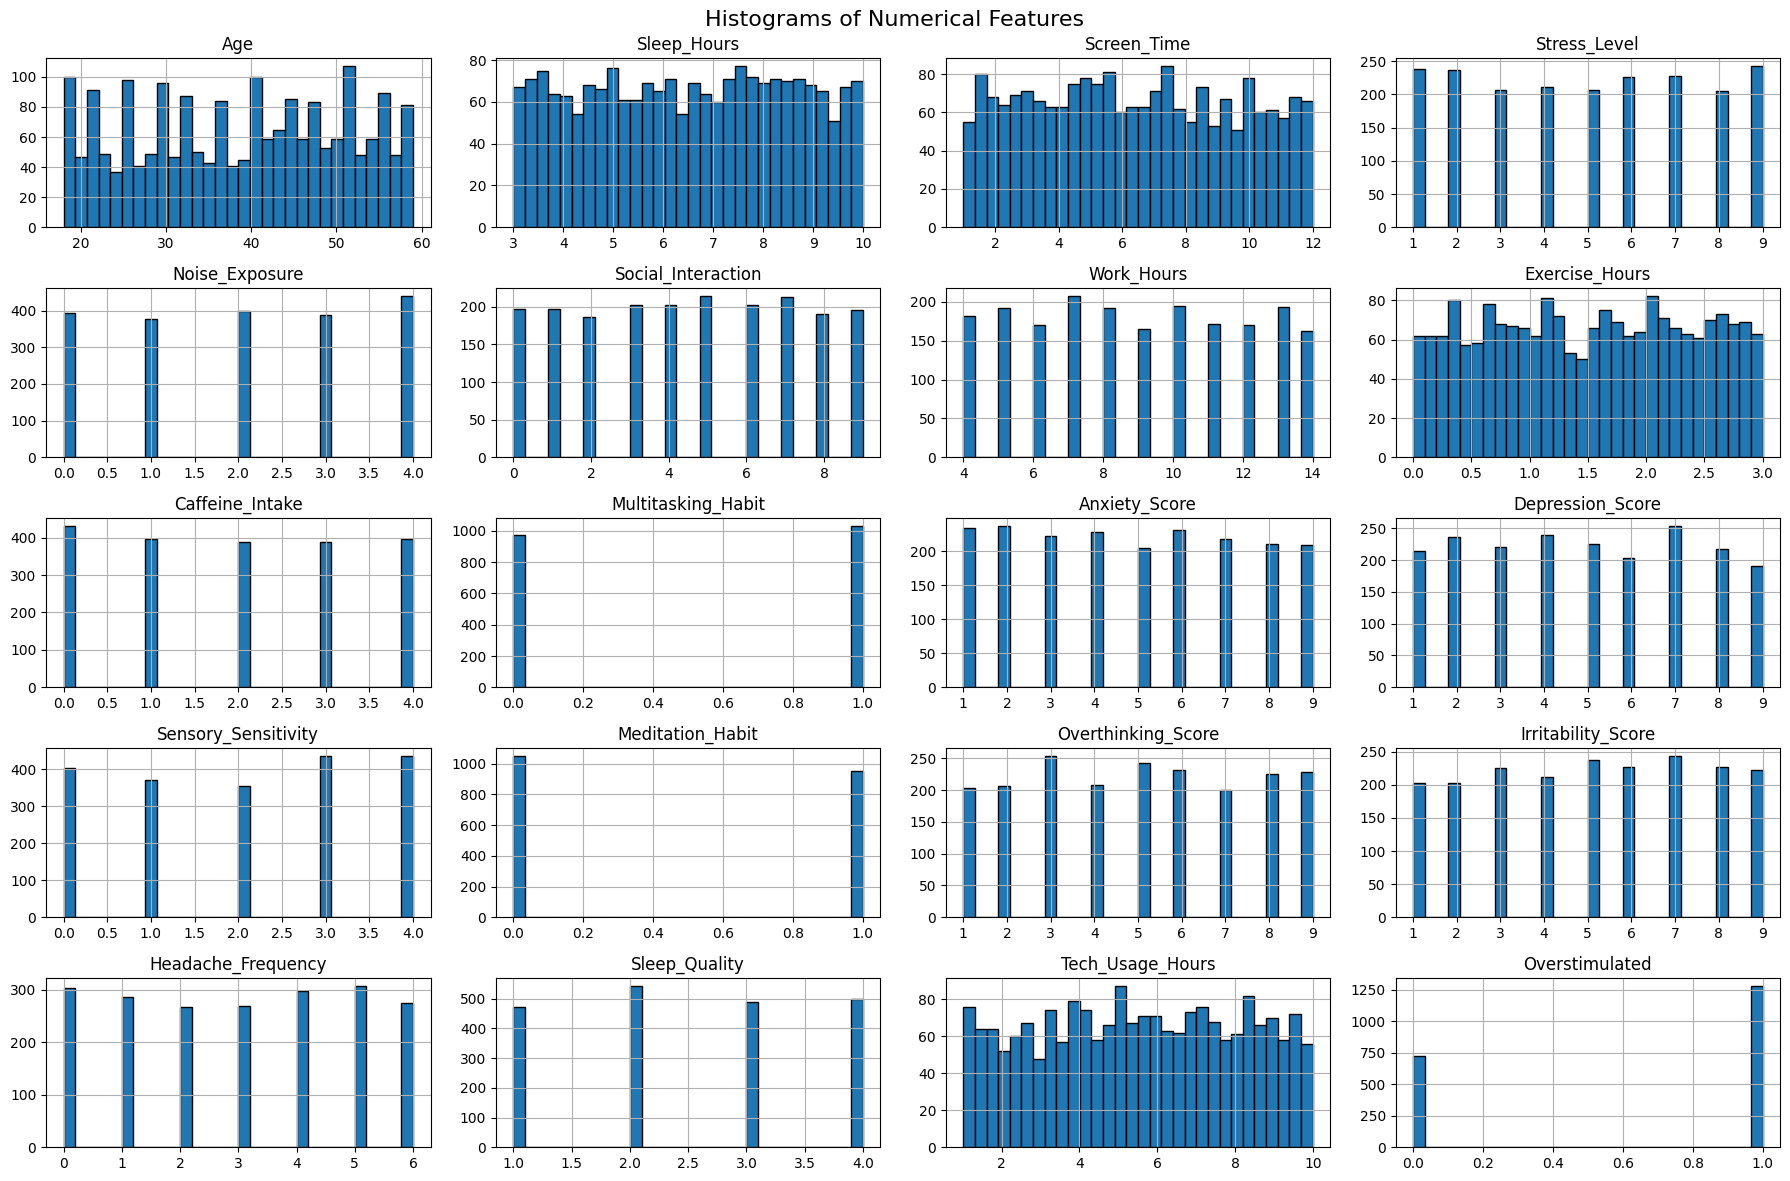

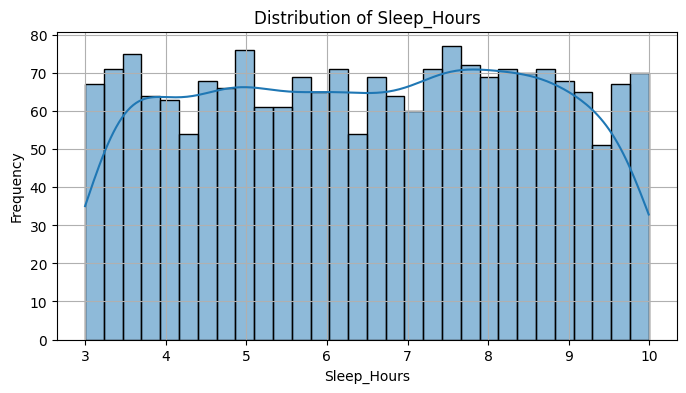

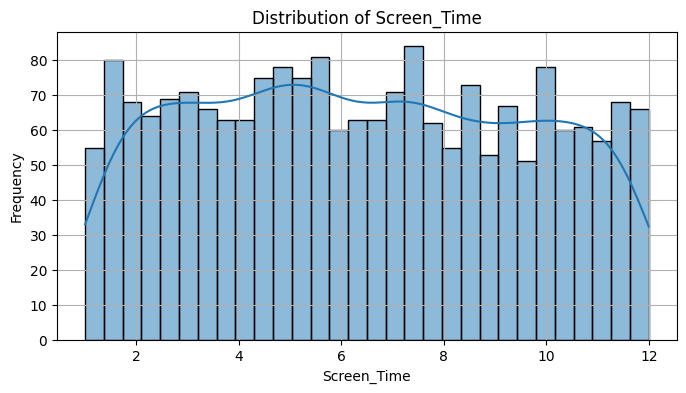

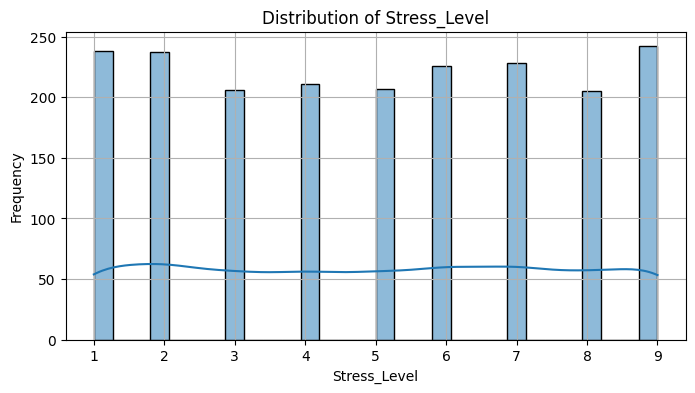

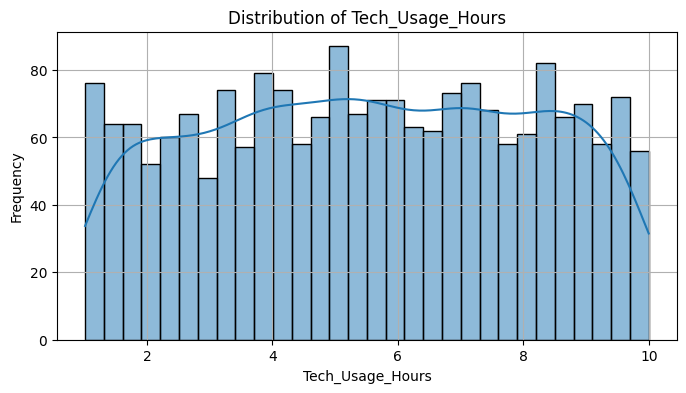

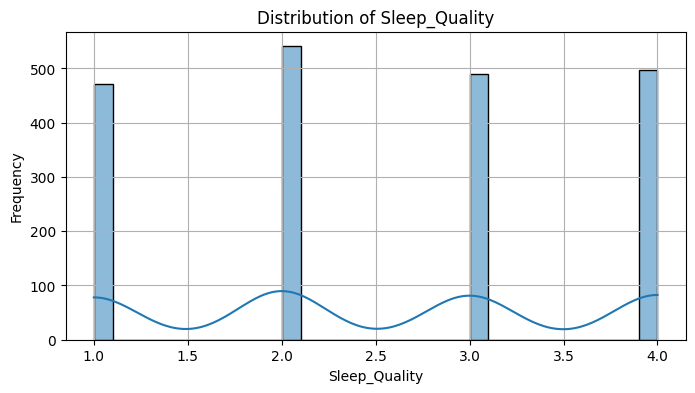

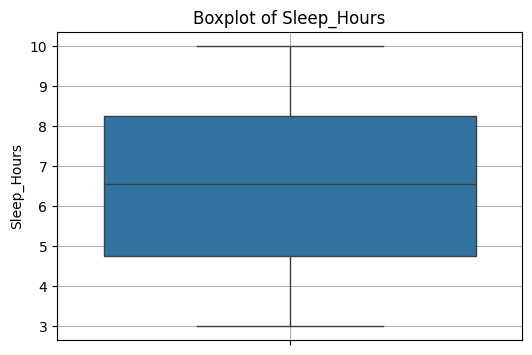

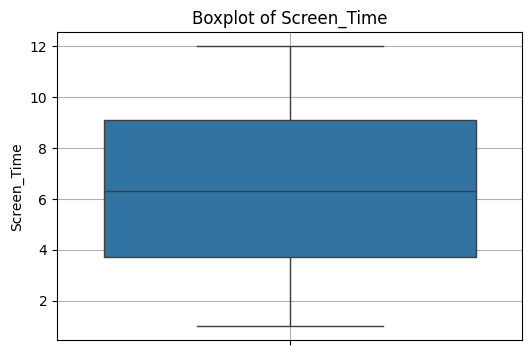

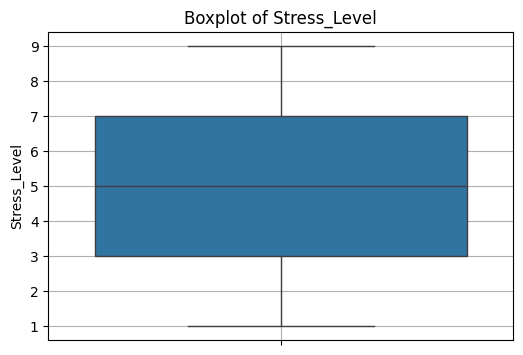

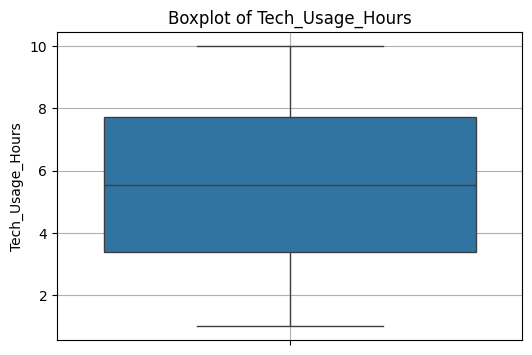

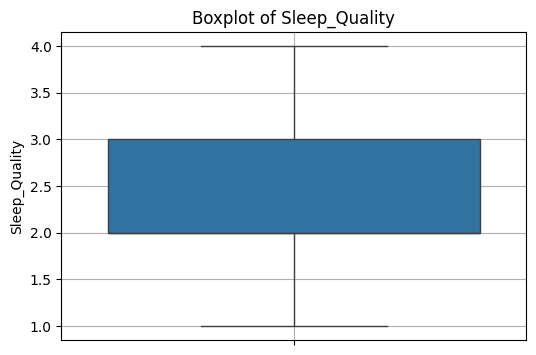

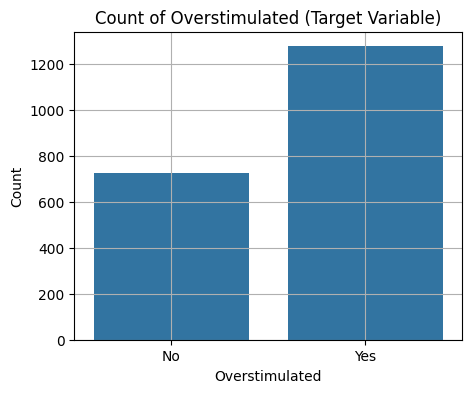

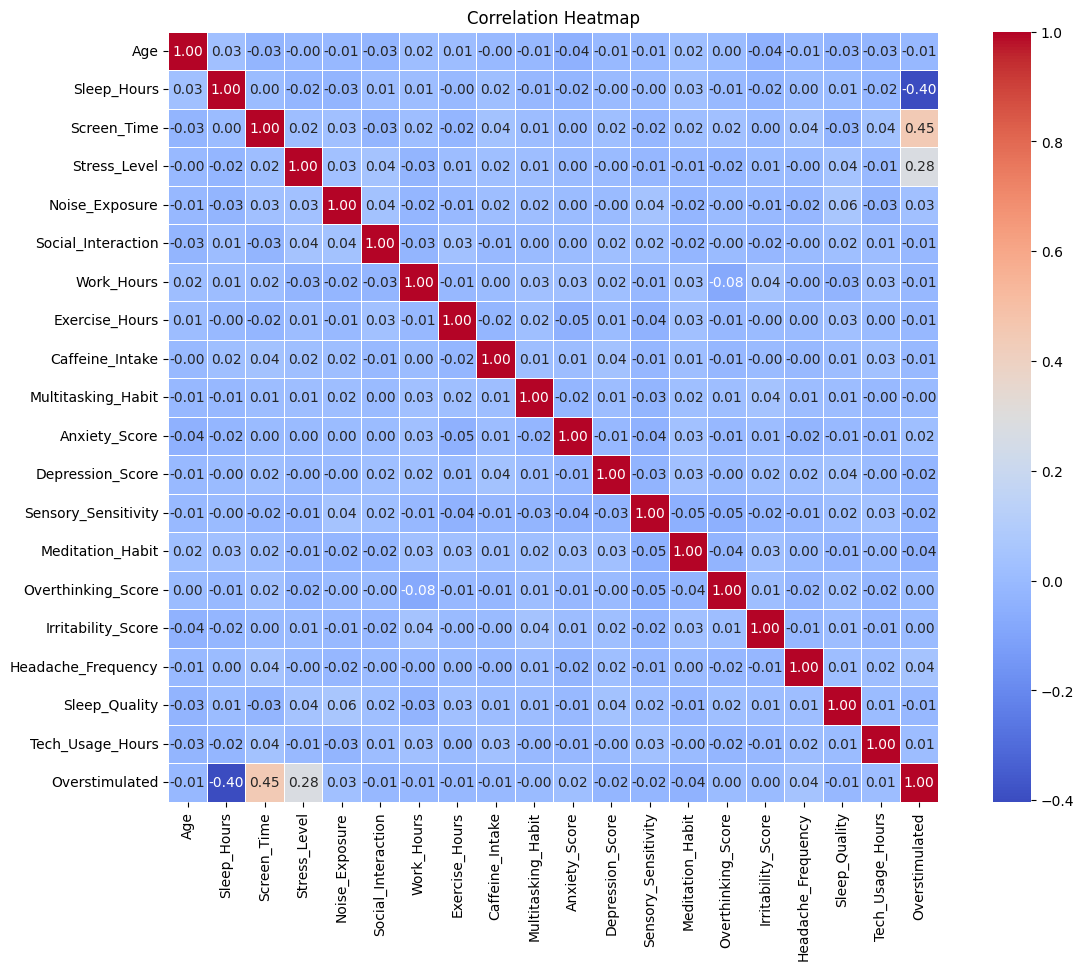

In [21]:
print(df.info())
print(df.describe())

# ------------------------------
# 1. Distribution of Numerical Features
# ------------------------------
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Histograms
df[numeric_cols].hist(figsize=(18, 12), bins=30, edgecolor='black')
plt.suptitle('Histograms of Numerical Features', fontsize=16)
plt.tight_layout()
plt.show()

# ------------------------------
# 2. Distribution Plots for Key Features
# ------------------------------
key_features = ['Sleep_Hours', 'Screen_Time', 'Stress_Level', 'Tech_Usage_Hours', 'Sleep_Quality']

for feature in key_features:
    plt.figure(figsize=(8, 4))
    sns.histplot(df[feature], kde=True, bins=30)
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Frequency')
    plt.grid(True)
    plt.show()

# ------------------------------
# 3. Boxplots to Detect Outliers
# ------------------------------
for feature in key_features:
    plt.figure(figsize=(6, 4))
    sns.boxplot(y=df[feature])
    plt.title(f'Boxplot of {feature}')
    plt.grid(True)
    plt.show()

# ------------------------------
# 4. Countplot for Target Variable
# ------------------------------
plt.figure(figsize=(5, 4))
sns.countplot(x='Overstimulated', data=df)
plt.title('Count of Overstimulated (Target Variable)')
plt.xlabel('Overstimulated')
plt.ylabel('Count')
plt.xticks([0, 1], ['No', 'Yes'])
plt.grid(True)
plt.show()

# ------------------------------
# 5. Correlation Heatmap
# ------------------------------
plt.figure(figsize=(14, 10))
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True, linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()


Correlations with Overstimulated:

Screen_Time            0.445316
Stress_Level           0.277017
Headache_Frequency     0.043190
Noise_Exposure         0.028797
Anxiety_Score          0.021336
Tech_Usage_Hours       0.012978
Overthinking_Score     0.003522
Irritability_Score     0.001465
Multitasking_Habit    -0.002055
Caffeine_Intake       -0.006752
Work_Hours            -0.009603
Sleep_Quality         -0.010422
Exercise_Hours        -0.010532
Social_Interaction    -0.012522
Age                   -0.012540
Sensory_Sensitivity   -0.020701
Depression_Score      -0.021327
Meditation_Habit      -0.038604
Sleep_Hours           -0.402738
Name: Overstimulated, dtype: float64


<ipython-input-24-5f84e3f45689>:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=overstim_corr_sorted.values, y=overstim_corr_sorted.index, palette="coolwarm")


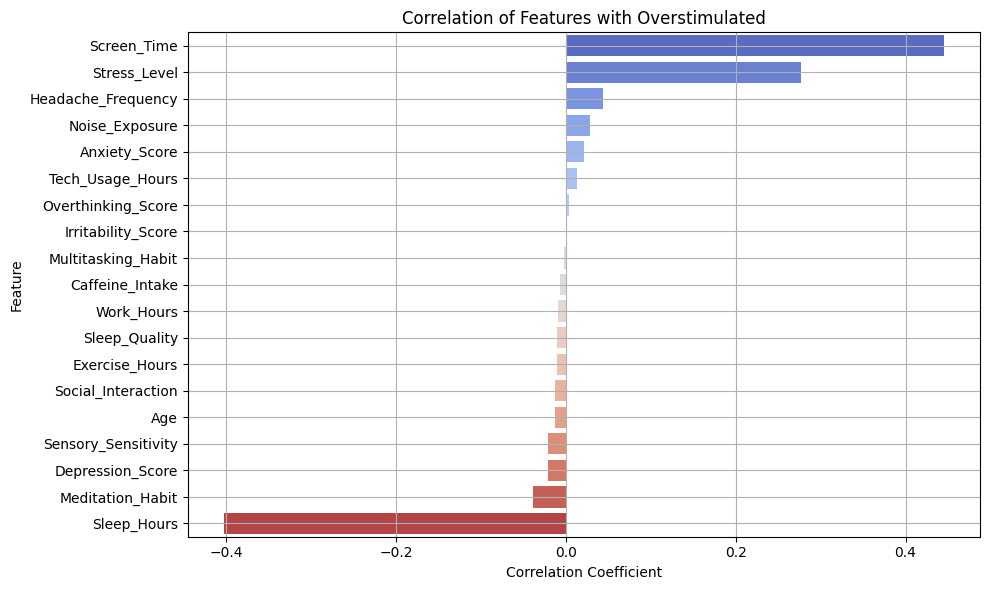

In [24]:
# Compute correlation matrix
correlation_matrix = df.corr(numeric_only=True)

# Extract correlation with Overstimulated
overstim_corr = correlation_matrix['Overstimulated'].drop('Overstimulated')  # Remove self-correlation

# Sort correlations by strength
overstim_corr_sorted = overstim_corr.sort_values(ascending=False)

# Display correlations
print("Correlations with Overstimulated:\n")
print(overstim_corr_sorted)

# --------------------------
# Visualization: Bar Plot
# --------------------------
plt.figure(figsize=(10, 6))
sns.barplot(x=overstim_corr_sorted.values, y=overstim_corr_sorted.index, palette="coolwarm")
plt.title("Correlation of Features with Overstimulated")
plt.xlabel("Correlation Coefficient")
plt.ylabel("Feature")
plt.grid(True)
plt.tight_layout()
plt.show()

In [27]:
# Import the necessary function
from scipy.stats import ttest_ind

In [28]:
# Split into groups
group_0 = df[df['Overstimulated'] == 0]
group_1 = df[df['Overstimulated'] == 1]

# Features to test
features_to_test = ['Sleep_Hours', 'Screen_Time', 'Stress_Level', 'Tech_Usage_Hours',
                    'Exercise_Hours', 'Sleep_Quality', 'Meditation_Habit', 'Caffeine_Intake']

# Store results
results = []

# Loop through features and perform t-tests
for feature in features_to_test:
    try:
        stat, p_value = ttest_ind(group_0[feature], group_1[feature], equal_var=False)
        results.append({
            'Feature': feature,
            'T-statistic': stat,
            'P-value': p_value,
            'Significant (p < 0.05)': p_value < 0.05
        })
    except Exception as e:
        print(f"Error performing t-test on {feature}: {e}")
        results.append({
            'Feature': feature,
            'T-statistic': None,
            'P-value': None,
            'Significant (p < 0.05)': None
        })

# Create results DataFrame
results_df = pd.DataFrame(results)
print(results_df.sort_values(by='P-value'))

# Features to test
features_to_test = ['Sleep_Hours', 'Screen_Time', 'Stress_Level', 'Tech_Usage_Hours',
                    'Exercise_Hours', 'Sleep_Quality', 'Meditation_Habit', 'Caffeine_Intake']

# Store results
results = []

# Loop through features and perform t-tests
for feature in features_to_test:
    stat, p_value = ttest_ind(group_0[feature], group_1[feature], equal_var=False)
    results.append({
        'Feature': feature,
        'T-statistic': stat,
        'P-value': p_value,
        'Significant (p < 0.05)': p_value < 0.05
    })

# Create results DataFrame
results_df = pd.DataFrame(results)
print(results_df.sort_values(by='P-value'))


            Feature  T-statistic        P-value  Significant (p < 0.05)
1       Screen_Time   -25.028232  2.552442e-120                    True
0       Sleep_Hours    21.655315   3.176804e-93                    True
2      Stress_Level   -13.985269   2.409064e-42                    True
6  Meditation_Habit     1.725351   8.467004e-02                   False
3  Tech_Usage_Hours    -0.577714   5.635451e-01                   False
4    Exercise_Hours     0.470132   6.383290e-01                   False
5     Sleep_Quality     0.468668   6.393734e-01                   False
7   Caffeine_Intake     0.299927   7.642754e-01                   False
            Feature  T-statistic        P-value  Significant (p < 0.05)
1       Screen_Time   -25.028232  2.552442e-120                    True
0       Sleep_Hours    21.655315   3.176804e-93                    True
2      Stress_Level   -13.985269   2.409064e-42                    True
6  Meditation_Habit     1.725351   8.467004e-02                 

In [30]:
# Import necessary libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression # Import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, RocCurveDisplay
import matplotlib.pyplot as plt
import seaborn as sns


📊 Performance of Logistic Regression
[[103  34]
 [ 34 229]]
              precision    recall  f1-score   support

           0       0.75      0.75      0.75       137
           1       0.87      0.87      0.87       263

    accuracy                           0.83       400
   macro avg       0.81      0.81      0.81       400
weighted avg       0.83      0.83      0.83       400

AUC Score: 0.900


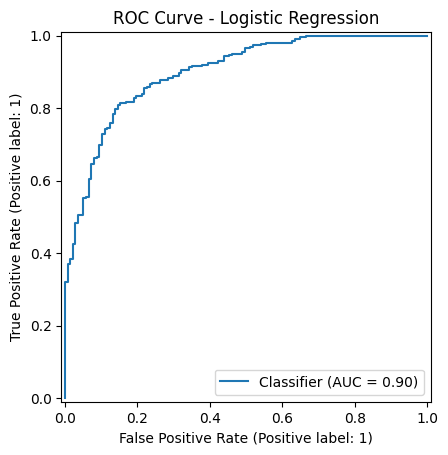


📊 Performance of Random Forest
[[137   0]
 [  0 263]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       137
           1       1.00      1.00      1.00       263

    accuracy                           1.00       400
   macro avg       1.00      1.00      1.00       400
weighted avg       1.00      1.00      1.00       400

AUC Score: 1.000


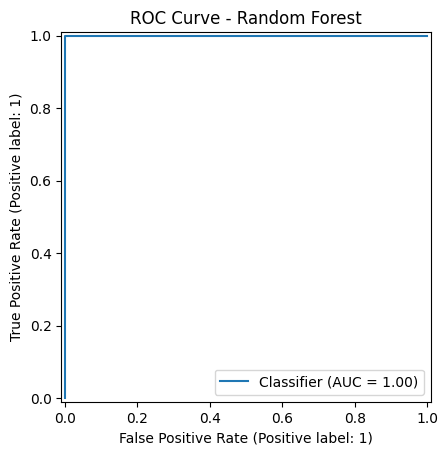


📊 Performance of Gradient Boosting
[[137   0]
 [  0 263]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       137
           1       1.00      1.00      1.00       263

    accuracy                           1.00       400
   macro avg       1.00      1.00      1.00       400
weighted avg       1.00      1.00      1.00       400

AUC Score: 1.000


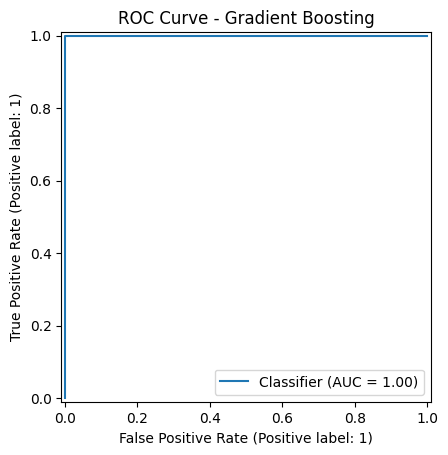

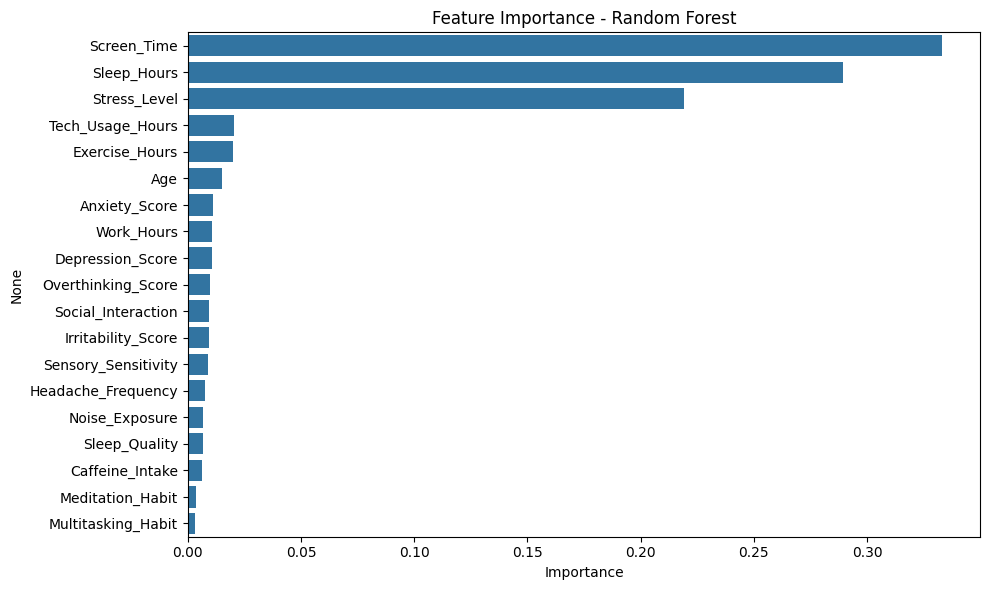

In [31]:
# Define features and target
X = df.drop(['Overstimulated'], axis=1)
y = df['Overstimulated']

# Normalize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# -------------------
# 1. Logistic Regression
# -------------------
log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)
y_pred_log = log_reg.predict(X_test)

# -------------------
# 2. Random Forest
# -------------------
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

# -------------------
# 3. Gradient Boosting
# -------------------
gb = GradientBoostingClassifier(random_state=42)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)

# -------------------
# Evaluation Function
# -------------------
def evaluate_model(y_test, y_pred, model_name, y_prob=None):
    print(f"\n📊 Performance of {model_name}")
    print(confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred))
    if y_prob is not None:
        auc_score = roc_auc_score(y_test, y_prob)
        print(f"AUC Score: {auc_score:.3f}")
        RocCurveDisplay.from_predictions(y_test, y_prob)
        plt.title(f"ROC Curve - {model_name}")
        plt.show()

# Evaluate all models
evaluate_model(y_test, y_pred_log, "Logistic Regression", log_reg.predict_proba(X_test)[:, 1])
evaluate_model(y_test, y_pred_rf, "Random Forest", rf.predict_proba(X_test)[:, 1])
evaluate_model(y_test, y_pred_gb, "Gradient Boosting", gb.predict_proba(X_test)[:, 1])

# -------------------
# Feature Importance (Random Forest)
# -------------------
importances = rf.feature_importances_
feature_names = df.drop('Overstimulated', axis=1).columns

feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=feat_imp.values, y=feat_imp.index)
plt.title('Feature Importance - Random Forest')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()


In [33]:
# Import DecisionTreeClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, RocCurveDisplay, accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

                     Accuracy  Precision    Recall  F1 Score   ROC AUC
Model                                                                 
Decision Tree            1.00   1.000000  1.000000  1.000000  1.000000
Random Forest            1.00   1.000000  1.000000  1.000000  1.000000
Gradient Boosting        1.00   1.000000  1.000000  1.000000  1.000000
Logistic Regression      0.83   0.870722  0.870722  0.870722  0.899697


<Figure size 1000x600 with 0 Axes>

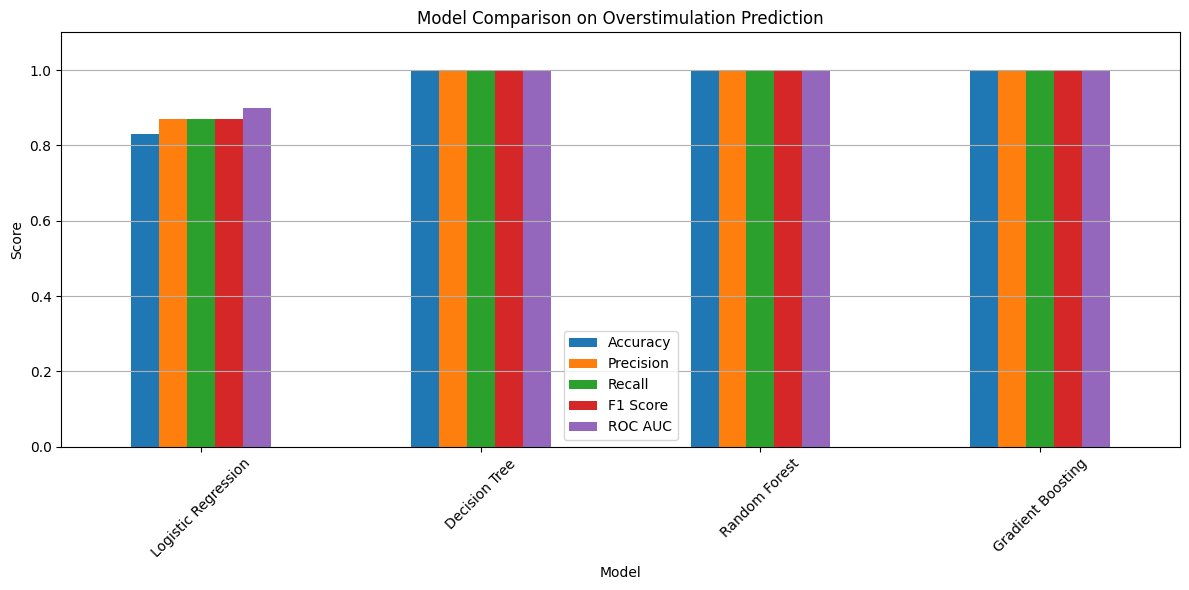

In [34]:
# Features and target
X = df.drop(['Overstimulated'], axis=1)
y = df['Overstimulated']

# Normalize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Define models
models = {
    'Logistic Regression': LogisticRegression(),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42)
}

# Store results
results = []

for model_name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    results.append({
        'Model': model_name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1 Score': f1_score(y_test, y_pred),
        'ROC AUC': roc_auc_score(y_test, y_prob)
    })

# Convert to DataFrame
results_df = pd.DataFrame(results).set_index('Model')
print(results_df.sort_values('F1 Score', ascending=False))

# Plot comparison
plt.figure(figsize=(10, 6))
results_df.plot(kind='bar', figsize=(12, 6))
plt.title("Model Comparison on Overstimulation Prediction")
plt.ylabel("Score")
plt.ylim(0, 1.1)
plt.grid(axis='y')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()